# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [2]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-04-22 22:16:40.376587: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [3]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "/Users/jonathanlu/Downloads/446 Lab3"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [4]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1

    # <-- Enter your code here <--#
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"), dtype=np.float32)
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt"), dtype=np.int32) - 1
    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"), dtype=np.float32)
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt"), dtype=np.int32) - 1

    return X_train, y_train, X_test, y_test
  
X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
num_features = X_train.shape[1]
num_classes = len(class_names)


## 5. Quick Inspection


In [5]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

# <-- Enter your code here <--#
label_counts = pd.Series(y_train).value_counts().sort_index()

class_summary = pd.DataFrame({
    "Class Index": np.arange(num_classes),
    "Class Name": class_names,
    "Training Samples": label_counts.reindex(np.arange(num_classes), fill_value=0).values,
})

class_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [6]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/40
92/92 [==============================] - 3s 11ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 1s 7ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 1s 6ms/step - loss: 0.1152 - accuracy: 0.9568 - val_loss: 0.2632 - val_accuracy: 0.9123
Epoch 4/40
92/92 [==============================] - 1s 8ms/step - loss: 0.0907 - accuracy: 0.9633 - val_loss: 0.1618 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 1s 8ms/step - loss: 0.0905 - accuracy: 0.9646 - val_loss: 0.2719 - val_accuracy: 0.9205
Epoch 6/40
92/92 [==============================] - 1s 8ms/step - loss: 0.0713 - accuracy: 0.9719 - val_loss: 0.2238 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 1s 7ms/step - loss: 0.0615 - accuracy: 0.9764 - val_loss: 0.1368 - val_accuracy: 0.9443
Epoch 8/40
92/92 [=

### Training Curves


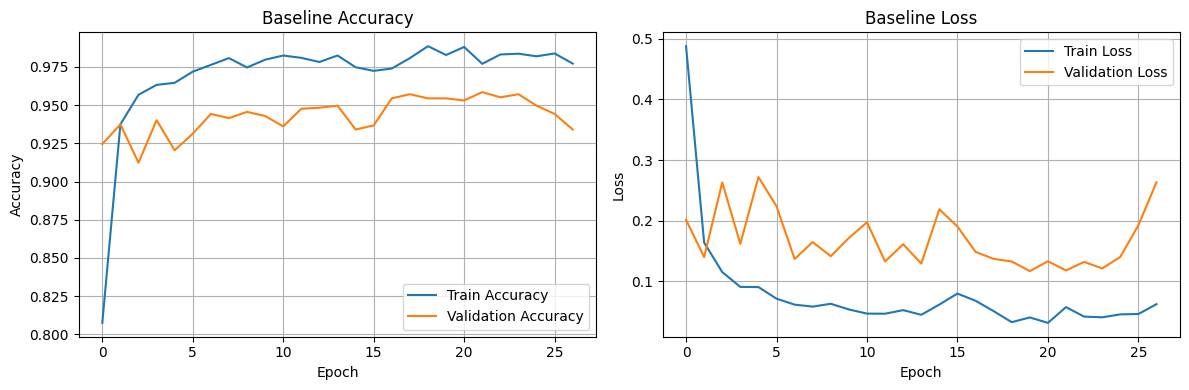

In [8]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#
history_df = pd.DataFrame(baseline_history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["accuracy"], label="Train Accuracy")
axes[0].plot(history_df["val_accuracy"], label="Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Baseline Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_df["loss"], label="Train Loss")
axes[1].plot(history_df["val_loss"], label="Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Baseline Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 7. Evaluate the Baseline Keras Model


Baseline Test Accuracy: 0.9362

                    precision    recall  f1-score   support

           WALKING     0.9108    0.9879    0.9478       496
  WALKING_UPSTAIRS     0.9477    0.8854    0.9155       471
WALKING_DOWNSTAIRS     0.9562    0.9357    0.9458       420
           SITTING     0.9596    0.8697    0.9124       491
          STANDING     0.8639    0.9662    0.9122       532
            LAYING     1.0000    0.9646    0.9820       537

          accuracy                         0.9362      2947
         macro avg     0.9397    0.9349    0.9359      2947
      weighted avg     0.9391    0.9362    0.9362      2947



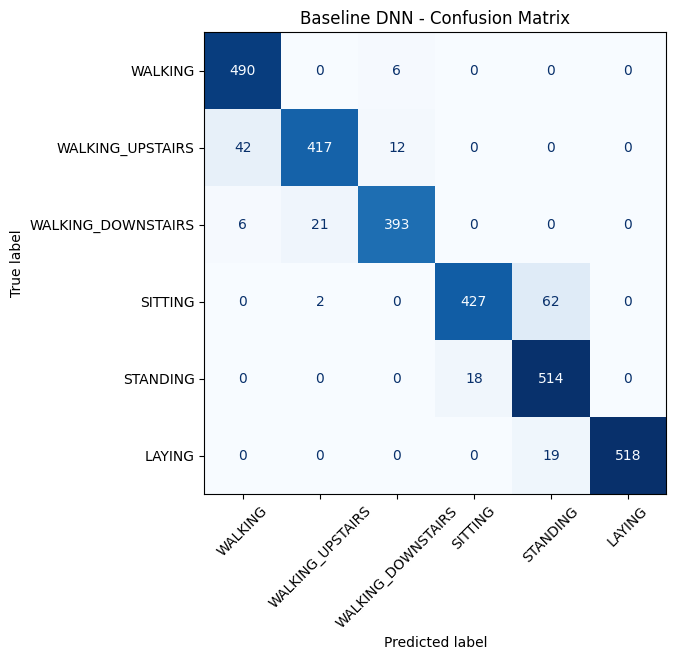

In [9]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
baseline_probs = baseline_model.predict(X_test, verbose=0)
baseline_preds = np.argmax(baseline_probs, axis=1)
baseline_acc = accuracy_score(y_test, baseline_preds)

print(f"Baseline Test Accuracy: {baseline_acc:.4f}\n")
print(classification_report(y_test, baseline_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, baseline_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Baseline DNN - Confusion Matrix")
plt.show()


## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [10]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]

    # <-- Enter your code here <--#
    for i in range(min(300, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#
        if input_details["dtype"] in (np.int8, np.uint8):
            qinfo = np.iinfo(input_details["dtype"])
            x = np.clip(np.round(x / input_scale + input_zero_point), qinfo.min, qinfo.max)
            x = x.astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.

        # <-- Enter your code here <--#
        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [11]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#
baseline_fp32_tflite = convert_to_tflite_fp32(baseline_model)
baseline_dynamic_tflite = convert_to_tflite_dynamic_range(baseline_model)
baseline_float16_tflite = convert_to_tflite_float16(baseline_model)
baseline_int8_tflite = convert_to_tflite_int8(baseline_model)

baseline_fp32_size_kb = save_binary_model(baseline_fp32_tflite, "baseline_fp32.tflite")
baseline_dynamic_size_kb = save_binary_model(baseline_dynamic_tflite, "baseline_dynamic_range.tflite")
baseline_float16_size_kb = save_binary_model(baseline_float16_tflite, "baseline_float16.tflite")
baseline_int8_size_kb = save_binary_model(baseline_int8_tflite, "baseline_int8.tflite")

baseline_fp32_tflite_acc, baseline_fp32_tflite_preds = evaluate_tflite_model(baseline_fp32_tflite, X_test, y_test)
baseline_dynamic_acc, baseline_dynamic_preds = evaluate_tflite_model(baseline_dynamic_tflite, X_test, y_test)
baseline_float16_acc, baseline_float16_preds = evaluate_tflite_model(baseline_float16_tflite, X_test, y_test)
baseline_int8_acc, baseline_int8_preds = evaluate_tflite_model(baseline_int8_tflite, X_test, y_test)


INFO:tensorflow:Assets written to: /var/folders/s5/cgn0_4y57gdc40t39z79fhlm0000gn/T/tmp4vrxt_fx/assets


INFO:tensorflow:Assets written to: /var/folders/s5/cgn0_4y57gdc40t39z79fhlm0000gn/T/tmp4vrxt_fx/assets
2026-04-22 22:17:21.991112: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 22:17:21.991396: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 22:17:21.993358: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/s5/cgn0_4y57gdc40t39z79fhlm0000gn/T/tmp4vrxt_fx
2026-04-22 22:17:21.996740: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 22:17:21.996767: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/s5/cgn0_4y57gdc40t39z79fhlm0000gn/T/tmp4vrxt_fx
2026-04-22 22:17:22.004740: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-22 22:17:22.008547: I tensorflow/cc/saved_model/load

INFO:tensorflow:Assets written to: /var/folders/s5/cgn0_4y57gdc40t39z79fhlm0000gn/T/tmpvlowtrsz/assets


INFO:tensorflow:Assets written to: /var/folders/s5/cgn0_4y57gdc40t39z79fhlm0000gn/T/tmpvlowtrsz/assets
2026-04-22 22:17:25.413160: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 22:17:25.413191: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 22:17:25.413601: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/s5/cgn0_4y57gdc40t39z79fhlm0000gn/T/tmpvlowtrsz
2026-04-22 22:17:25.417047: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 22:17:25.417077: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/s5/cgn0_4y57gdc40t39z79fhlm0000gn/T/tmpvlowtrsz
2026-04-22 22:17:25.443311: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 22:17:25.786034: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/s5/cgn0_4y57gdc40t39z79fhlm0000gn/T/tmprox3cxeu/assets


INFO:tensorflow:Assets written to: /var/folders/s5/cgn0_4y57gdc40t39z79fhlm0000gn/T/tmprox3cxeu/assets
2026-04-22 22:17:33.585227: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 22:17:33.585273: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 22:17:33.585687: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/s5/cgn0_4y57gdc40t39z79fhlm0000gn/T/tmprox3cxeu
2026-04-22 22:17:33.588289: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 22:17:33.588313: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/s5/cgn0_4y57gdc40t39z79fhlm0000gn/T/tmprox3cxeu
2026-04-22 22:17:33.595773: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 22:17:33.908002: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/s5/cgn0_4y57gdc40t39z79fhlm0000gn/T/tmpjttr_4xu/assets


INFO:tensorflow:Assets written to: /var/folders/s5/cgn0_4y57gdc40t39z79fhlm0000gn/T/tmpjttr_4xu/assets
/Users/jonathanlu/Downloads/anaconda3/envs/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-22 22:17:37.705768: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 22:17:37.705792: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 22:17:37.706071: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/s5/cgn0_4y57gdc40t39z79fhlm0000gn/T/tmpjttr_4xu
2026-04-22 22:17:37.708648: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 22:17:37.708672: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/

## 10. PTQ Comparison: Accuracy and Model Size


In [12]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
quantization_results = pd.DataFrame([
    ["Baseline DNN", "Keras FP32", baseline_acc, np.nan],
    ["Baseline DNN", "TFLite FP32", baseline_fp32_tflite_acc, baseline_fp32_size_kb],
    ["Baseline DNN", "TFLite Dynamic Range", baseline_dynamic_acc, baseline_dynamic_size_kb],
    ["Baseline DNN", "TFLite Float16", baseline_float16_acc, baseline_float16_size_kb],
    ["Baseline DNN", "TFLite INT8", baseline_int8_acc, baseline_int8_size_kb],
], columns=["Model Family", "Format", "Test Accuracy", "Model Size (KB)"])

quantization_results


,Model Family,Format,Test Accuracy,Model Size (KB)
0,Baseline DNN,Keras FP32,0.936206,NaN
1,Baseline DNN,TFLite FP32,0.936206,726.718750
2,Baseline DNN,TFLite Dynamic Range,0.936546,186.109375
3,Baseline DNN,TFLite Float16,0.936206,365.710938
4,Baseline DNN,TFLite INT8,0.935867,185.335938


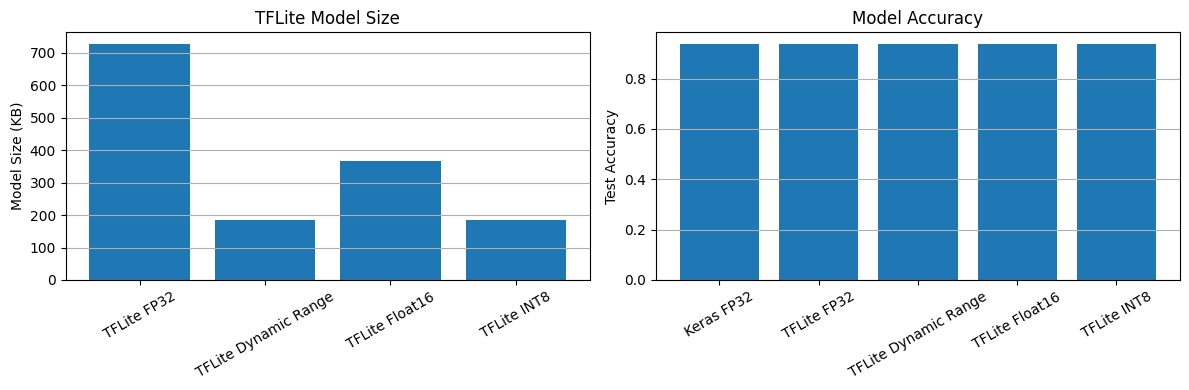

In [13]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#
plot_results = quantization_results.dropna(subset=["Model Size (KB)"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(plot_results["Format"], plot_results["Model Size (KB)"])
axes[0].set_ylabel("Model Size (KB)")
axes[0].set_title("TFLite Model Size")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y")

axes[1].bar(quantization_results["Format"], quantization_results["Test Accuracy"])
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Model Accuracy")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()


### Confusion Matrix for the PTQ Int8 Model


                    precision    recall  f1-score   support

           WALKING     0.9108    0.9879    0.9478       496
  WALKING_UPSTAIRS     0.9477    0.8854    0.9155       471
WALKING_DOWNSTAIRS     0.9562    0.9357    0.9458       420
           SITTING     0.9596    0.8697    0.9124       491
          STANDING     0.8624    0.9662    0.9113       532
            LAYING     1.0000    0.9628    0.9810       537

          accuracy                         0.9359      2947
         macro avg     0.9394    0.9346    0.9356      2947
      weighted avg     0.9388    0.9359    0.9359      2947



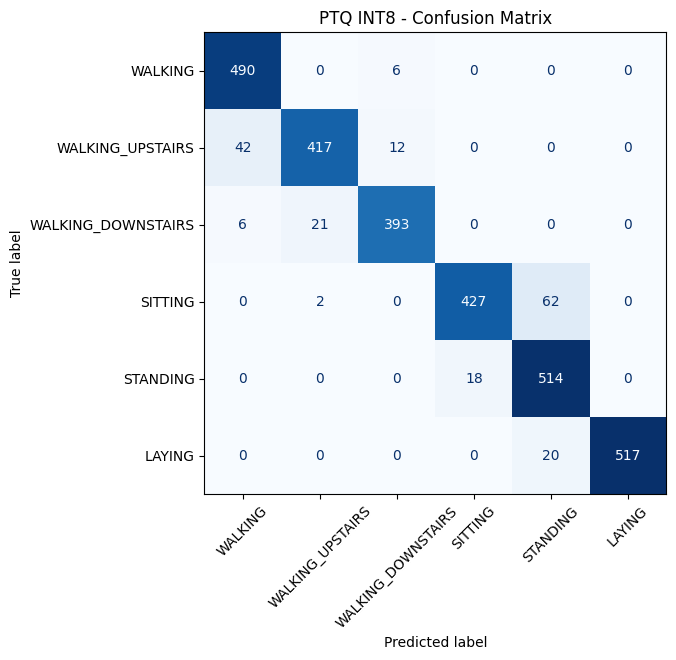

In [14]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#
print(classification_report(y_test, baseline_int8_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, baseline_int8_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("PTQ INT8 - Confusion Matrix")
plt.show()


## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [15]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
quantize_model = tfmot.quantization.keras.quantize_model
qat_model = quantize_model(baseline_model)
qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

qat_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_dense (QuantizeWrapp  (None, 256)               143877    
 erV2)                                                           
                                                                 
 quant_dense_1 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_2 (QuantizeWra  (None, 64)                8261      
 pperV2)                                                         
                                                                 
 quant_dense_3 (QuantizeWra  (None, 6)                 3

### Fine-Tune the QAT Model


In [16]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#
qat_history = qat_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1,
)


Epoch 1/8
92/92 [==============================] - 4s 15ms/step - loss: 0.0310 - accuracy: 0.9896 - val_loss: 0.1236 - val_accuracy: 0.9579
Epoch 2/8
92/92 [==============================] - 1s 9ms/step - loss: 0.0258 - accuracy: 0.9910 - val_loss: 0.1282 - val_accuracy: 0.9572
Epoch 3/8
92/92 [==============================] - 1s 8ms/step - loss: 0.0247 - accuracy: 0.9923 - val_loss: 0.1263 - val_accuracy: 0.9579
Epoch 4/8
92/92 [==============================] - 1s 10ms/step - loss: 0.0227 - accuracy: 0.9918 - val_loss: 0.1252 - val_accuracy: 0.9585
Epoch 5/8
92/92 [==============================] - 1s 11ms/step - loss: 0.0211 - accuracy: 0.9935 - val_loss: 0.1447 - val_accuracy: 0.9551
Epoch 6/8
92/92 [==============================] - 1s 9ms/step - loss: 0.0228 - accuracy: 0.9906 - val_loss: 0.1457 - val_accuracy: 0.9565
Epoch 7/8
92/92 [==============================] - 1s 9ms/step - loss: 0.0205 - accuracy: 0.9922 - val_loss: 0.1308 - val_accuracy: 0.9592
Epoch 8/8
92/92 [=======

### Evaluate the QAT Keras Model


In [17]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#
qat_probs = qat_model.predict(X_test, verbose=0)
qat_preds = np.argmax(qat_probs, axis=1)
qat_acc = accuracy_score(y_test, qat_preds)

print(f"QAT Keras Test Accuracy: {qat_acc:.4f}\n")
print(classification_report(y_test, qat_preds, target_names=class_names, digits=4))


QAT Keras Test Accuracy: 0.9359

                    precision    recall  f1-score   support

           WALKING     0.9295    0.9839    0.9559       496
  WALKING_UPSTAIRS     0.9270    0.9172    0.9221       471
WALKING_DOWNSTAIRS     0.9625    0.9167    0.9390       420
           SITTING     0.9574    0.8697    0.9114       491
          STANDING     0.8591    0.9624    0.9078       532
            LAYING     1.0000    0.9572    0.9781       537

          accuracy                         0.9359      2947
         macro avg     0.9393    0.9345    0.9357      2947
      weighted avg     0.9386    0.9359    0.9361      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [18]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#
qat_int8_tflite = convert_to_tflite_int8(qat_model)
qat_int8_size_kb = save_binary_model(qat_int8_tflite, "qat_int8.tflite")
qat_int8_acc, qat_int8_preds = evaluate_tflite_model(qat_int8_tflite, X_test, y_test)

print(f"QAT INT8 Accuracy: {qat_int8_acc:.4f}")
print(f"QAT INT8 Size (KB): {qat_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /var/folders/s5/cgn0_4y57gdc40t39z79fhlm0000gn/T/tmpblp4mpfl/assets


INFO:tensorflow:Assets written to: /var/folders/s5/cgn0_4y57gdc40t39z79fhlm0000gn/T/tmpblp4mpfl/assets
/Users/jonathanlu/Downloads/anaconda3/envs/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-22 22:17:59.027192: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 22:17:59.027216: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 22:17:59.027733: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/s5/cgn0_4y57gdc40t39z79fhlm0000gn/T/tmpblp4mpfl
2026-04-22 22:17:59.035395: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 22:17:59.035418: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/

QAT INT8 Accuracy: 0.9359
QAT INT8 Size (KB): 185.70


## 12. PTQ Int8 vs QAT Int8


In [19]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
qat_comparison = pd.DataFrame([
    ["PTQ INT8", baseline_int8_acc, baseline_int8_size_kb],
    ["QAT INT8", qat_int8_acc, qat_int8_size_kb],
], columns=["Model", "Test Accuracy", "Model Size (KB)"])

qat_comparison


,Model,Test Accuracy,Model Size (KB)
0,PTQ INT8,0.935867,185.335938
1,QAT INT8,0.935867,185.695312


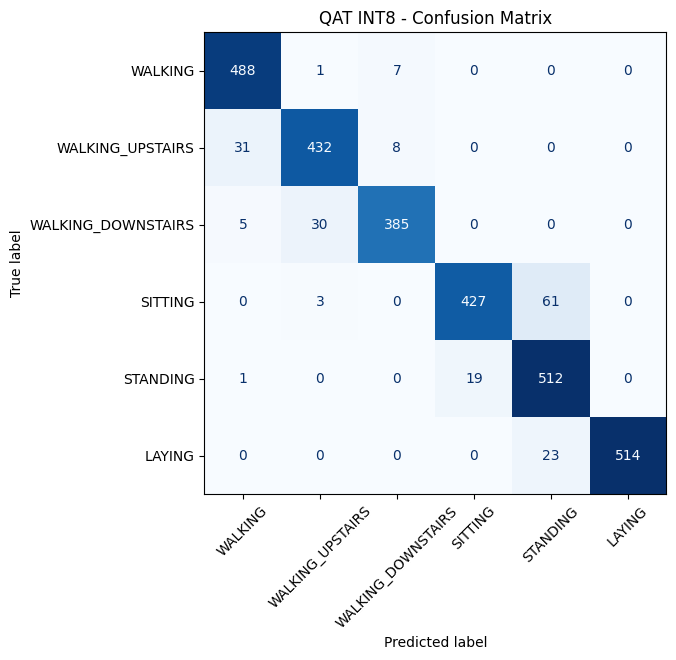

In [20]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, qat_int8_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("QAT INT8 - Confusion Matrix")
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
3. Did QAT improve the final int8 model compared with PTQ int8?
4. Why is this dataset a good fit for a DNN-based TinyML workflow?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
